In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
# import sys
from dotenv import load_dotenv
load_dotenv()

DATA_SOURCE_PATH = os.getenv("DATA_SOURCE_PATH", "../data/raw/")
HOUSE_DATASET_FILENAME = os.getenv("HOUSE_DATASET_FILENAME", "house_dataset.csv")
SOURCE_PATH = os.getenv("SOURCE_PATH", "../src/")

# Add src to path for custom modules
# sys.path.append(SOURCE_PATH)

# Set style
plt.style.use('default')
sns.set_palette("husl")

print("✅ Environment setup complete!")

✅ Environment setup complete!


In [4]:
# Load your house price dataset
data_path = Path(DATA_SOURCE_PATH)
df = pd.read_csv(data_path / HOUSE_DATASET_FILENAME)

print(f"Dataset shape: {df.shape}")

Dataset shape: (9200, 18)


Dataset shape after clean: (4602, 18)


In [ ]:
# #filter price is 0

# # Set your threshold
# threshold = 1

# # Filter the dataframe
# low_price_df = df[df['price'] < threshold]

# # Get the count
# count = len(low_price_df)
# percentage = (count / len(df)) * 100

# print(f"Number of houses priced below {threshold}: {count}")
# print(f"Percentage of total data: {percentage:.2f}%")
# Number of houses priced below 1: 98
# Percentage of total data: 1.07%

# Set your threshold
# threshold = 5e6

# # Filter the dataframe
# high_price_df = df_clean[df_clean['price'] > threshold]

# # Get the count
# count = len(high_price_df)
# percentage = (count / len(df_clean)) * 100

# print(f"Number of houses priced below {threshold}: {count}")
# print(f"Percentage of total data: {percentage:.2f}%")
#  # shall we remove outliner (~1%) or we use clip data to handle outliner (~1%) ?

In [45]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.copy()
    
    # cleaning functions

    # Remove rows where price is 0 or negative or more than 5 million (outliers)
    # df_clean = df_clean[(df_clean['price'] > 1) & (df_clean['price'] < 5e6)]
    # print(f"Removed {len(df) - len(df_clean)} rows with non-positive or outlier prices.")
    df_clean['price'] = handle_outliers(df_clean['price'], method='percentile', lower_bound=0.02, upper_bound=0.99)
    
    # (Use the code from previous analysis)
    
    return df_clean

def handle_outliers(series: pd.Series, method: str = 'percentile', lower_bound: float = 0.01, upper_bound: float = 0.99) -> pd.Series:
    if method == 'iqr':
        Q1 = series.quantile(0.25) # Standard IQR uses 25/75
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
    else: # 'percentile' method
        lower = series.quantile(lower_bound)
        upper = series.quantile(upper_bound)
        
    return series.clip(lower, upper)

# Because almost 50% of the data is duplicated, we will drop duplicates to get a more accurate analysis.
df_cleaned = df.drop_duplicates()
print(f"Dataset shape after clean: {df_cleaned.shape}")

# Now we can apply the cleaning function to the dataset.
df_clean = clean_data(df_cleaned)

# convert date(2014-05-02 00:00:00) to datetime
df_clean['date'] = pd.to_datetime(df_clean['date'])

# remove country column if exists (since all data is from the same country, it won't add value to the model)
df_clean.drop(columns=['country'], errors='ignore', inplace=True)


print("✅ Data cleaning completed!")
print(len(df_clean))
# Save cleaned data
df_clean.to_csv('../data/processed/cleaned_house_data.csv', index=False)

Dataset shape after clean: (4602, 18)
✅ Data cleaning completed!
4602


In [46]:
print("\n=== STATISTICAL SUMMARY ===")
print(df_clean.describe(percentiles=[.01, .25, .5, .75, .99]))


=== STATISTICAL SUMMARY ===
                                date         price     bedrooms    bathrooms  \
count                           4602  4.602000e+03  4602.000000  4602.000000   
mean   2014-06-07 03:32:27.848761344  5.395763e+05     3.400261     2.160637   
min              2014-05-02 00:00:00  1.425500e+05     0.000000     0.000000   
1%               2014-05-02 00:00:00  1.425500e+05     2.000000     1.000000   
25%              2014-05-21 00:00:00  3.226250e+05     3.000000     1.750000   
50%              2014-06-09 00:00:00  4.609435e+05     3.000000     2.250000   
75%              2014-06-24 00:00:00  6.549875e+05     4.000000     2.500000   
99%              2014-07-09 00:00:00  2.004900e+06     6.000000     4.500000   
max              2014-07-10 00:00:00  2.004950e+06     9.000000     8.000000   
std                              NaN  3.253896e+05     0.909359     0.783813   

        sqft_living      sqft_lot       floors   waterfront         view  \
count   4602.0

In [47]:
print(f"Dataset shape: {df_clean.shape}")
df_clean.head()

Dataset shape: (4602, 17)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133
1,2014-05-02,2004950.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052


Text(0, 0.5, 'Frequency')

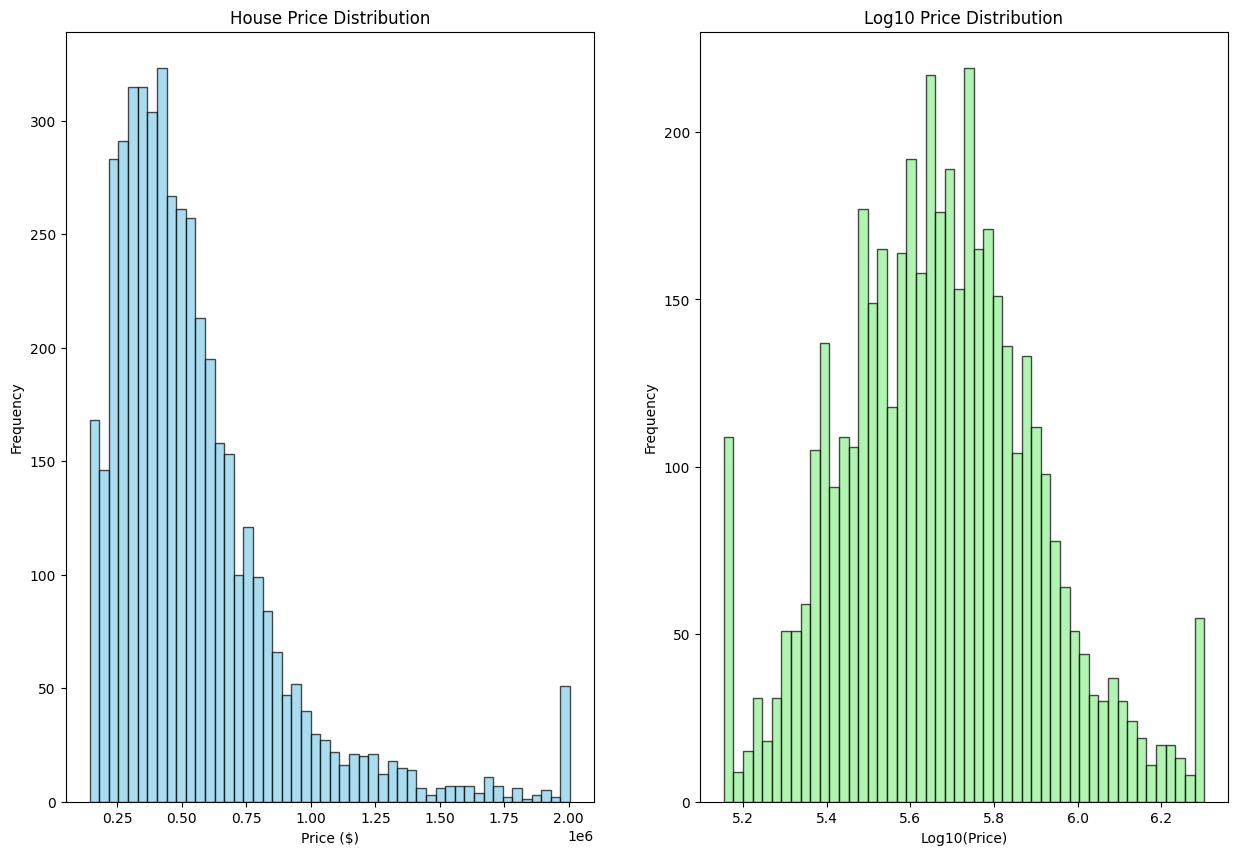

In [48]:
#DATA EXPLORATION
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
fig_size = (15, 10)

# 1. Price Distribution Analysis
fig, axes = plt.subplots(1, 2, figsize=fig_size)

# Price histogram
axes[0].hist(df_clean['price'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].set_title('House Price Distribution')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')

# Log-transformed price (often more normal)
# using log1p instead of log10 to handle zero or negative values if any
axes[1].hist(np.log10(df_clean['price']), bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1].set_title('Log10 Price Distribution')
axes[1].set_xlabel('Log10(Price)')
axes[1].set_ylabel('Frequency')